In [1]:
import re
import pandas as pd
import numpy as np
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import RegexpTokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Helper Functions

In [3]:
stop_words = set(stopwords.words('english'))
stop_words.update(['@', 'RT'])

def lower_order(text):
    return text.lower()

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emoji(string):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r' ', string)

def remove_unwanted(text):
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    text = re.sub(r'[^0-9A-Za-z ]', '', text)
    text = remove_emoji(text)
    text = text.replace('  ', ' ')
    return text.strip()

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

def lemmatize(tokens):
    wn = WordNetLemmatizer()
    return [wn.lemmatize(t, pos='v') for t in tokens]

def stem(tokens):
    ps = PorterStemmer()
    return [ps.stem(t) for t in tokens]

## Text Cleaning Pipeline

In [4]:
def text_cleaning_pipeline(text, rule='lemmatize'):
    text = lower_order(text)
    text = remove_urls(text)
    text = remove_emoji(text)
    text = remove_unwanted(text)
    tokens = text.split()
    tokens = remove_stopwords(tokens)
    if rule == 'lemmatize':
        tokens = lemmatize(tokens)
    elif rule == 'stem':
        tokens = stem(tokens)
    return ' '.join(tokens)

# quick test
sample = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free! #sushiBros"
print(text_cleaning_pipeline(sample))

hello still want us hit new sushi spot lmk youre free


# Text Classification using Machine Learning Models


### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column. This should include:
   - Lowercasing the text  
   - Removing URLs, mentions, punctuation, and special characters  
   - Removing stopwords  
   - Tokenization (optional: stemming or lemmatization)
   - "Complete the above function"

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into **training** and **testing** sets using `train_test_split` from `sklearn.model_selection`.

4. **TF-IDF Vectorization**  
   Import and use the `TfidfVectorizer` from `sklearn.feature_extraction.text` to transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Import **Logistic Regression** (or any machine learning model of your choice) from `sklearn.linear_model`. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.  
   - Print the **classification report** using `classification_report` from `sklearn.metrics`.


## Step 1 - Load the data

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Copy of trum_tweet_sentiment_analysis.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(1850123, 2)
['text', 'Sentiment']


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


## Step 2 - Clean the text

In [6]:
def text_cleaning_pipeline(text, rule='lemmatize'):
    text = lower_order(text)
    text = remove_urls(text)
    text = remove_emoji(text)
    text = remove_unwanted(text)
    tokens = text.split()
    tokens = remove_stopwords(tokens)
    if rule == 'lemmatize':
        tokens = lemmatize(tokens)
    elif rule == 'stem':
        tokens = stem(tokens)
    return ' '.join(tokens)

# quick test
sample = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free! #sushiBros"
print(text_cleaning_pipeline(sample))

hello still want us hit new sushi spot lmk youre free


## Step 1 – Load the Dataset


In [8]:
df = pd.read_csv("/content/drive/MyDrive/Copy of trum_tweet_sentiment_analysis.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(1850123, 2)
['text', 'Sentiment']


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


## Step 2 – Text Cleaning and Tokenisation


In [9]:
df['cleaned_text'] = df['text'].dropna().apply(
    lambda x: text_cleaning_pipeline(str(x), rule='lemmatize')
)

df = df[df['text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])

print(f"Dataset size after cleaning: {df.shape}")
df[['text', 'cleaned_text']].head()

Dataset size after cleaning: (1850123, 3)


,text,cleaned_text
0,RT @JohnLeguizamo: #trump not draining swamp b...,rt drain swamp taxpayer dollars trip advertise...
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play antitr...
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york via
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi im piers morgan david beckham awful donald ...
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,rt tech firm sue buzzfeed publish unverified t...


## Step 3 - Train/test split

In [10]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'train: {len(X_train)}, test: {len(X_test)}')

train: 1480098, test: 370025


## Step 4 - TF-IDF vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(1480098, 10000) (370025, 10000)


## Step 5 - Train and evaluate

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

           0       0.93      0.95      0.94    248842
           1       0.90      0.86      0.88    121183

    accuracy                           0.92    370025
   macro avg       0.92      0.91      0.91    370025
weighted avg       0.92      0.92      0.92    370025

accuracy: 0.9233


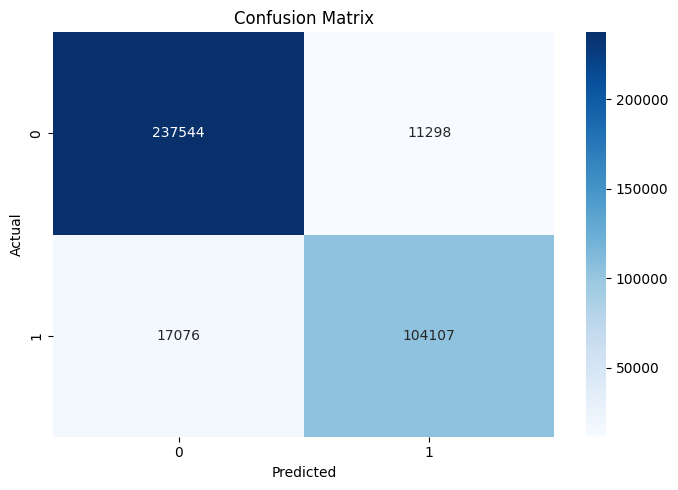

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()